## Setup

In [1]:
import os, warnings, random, time, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              average_precision_score, roc_curve)
import xgboost as xgb
import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED); np.random.seed(GLOBAL_SEED); torch.manual_seed(GLOBAL_SEED)

BASE_DIR = os.getcwd()
CACHE_DIR = os.path.join(BASE_DIR, "data_cache")   # expects erged_df_clean.csv.gz / erged_df_spike.csv.gz

VAE_EPOCHS, VAE_BATCH, VAE_LR = 50, 16, 1e-3
VAE_SEQ_LEN, VAE_LATENT_DIM, VAE_TRAIN_FRAC, BETA = 24, 4, 0.80, 0.5
ANOMALY_THRESHOLD = 0.15   # consistent everywhere in this notebook

MAX_CHARGE_MW = MAX_DISCHARGE_MW = CAPACITY_MWH = 10.0
EFFICIENCY, TRANSACTION_FEE, DEGRADATION_COST = 0.90, 0.5, 2.5
mcp, mdp, e, fee, degradation_cost = MAX_CHARGE_MW, MAX_DISCHARGE_MW, EFFICIENCY, TRANSACTION_FEE, DEGRADATION_COST
VALID_MODES = {"baseline", "penalised", "opportunistic"}


## 1. Data loading (cache-first, unchanged from original)

In [2]:
def _load_df(path):
    df = pd.read_csv(path, compression="gzip")
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"])
    return df

merged_df_clean = _load_df(os.path.join(CACHE_DIR, "erged_df_clean.csv.gz"))
merged_df_spike_raw_nodes = _load_df(os.path.join(CACHE_DIR, "erged_df_spike.csv.gz"))
print("Clean:", merged_df_clean.shape, " Spike (raw, pre-injection):", merged_df_spike_raw_nodes.shape)

def prepare_timeseries(df):
    df = df.copy()
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"])
        df = df.sort_values("datetime").reset_index(drop=True)
    agg = {c: "mean" for c in ["SP15", "NonSpin", "RegDown", "RegUp", "Spin"] if c in df.columns}
    df_ts = df.groupby("datetime").agg(agg).reset_index() if "datetime" in df.columns else df.copy()
    df_ts["expected_price"] = df_ts["SP15"].rolling(24, min_periods=1).mean().ffill().bfill()
    return df_ts.sort_values("datetime").reset_index(drop=True)


Clean: (77832, 9)  Spike (raw, pre-injection): (77832, 9)


## 2. Spike injection — FIXED

Injects directly on the aggregated hourly series (one row per hour) instead of the raw
3-node-interleaved rows, so the ground-truth mask exactly matches the injected magnitude with
no dilution.

In [3]:
def inject_fake_spikes(df, num_spikes=8, spike_duration=4, spike_magnitude=1.8,
                        non_revert_fraction=0.4, random_seed=42, return_mask=False):
    rng = np.random.default_rng(random_seed)
    df = df.copy().reset_index(drop=True)
    n = len(df)
    baseline = df["SP15"].median()
    safe_idx = np.arange(0, max(n - 7 * 24, 1))
    starts = sorted(rng.choice(safe_idx, size=min(num_spikes, len(safe_idx)), replace=False).tolist())
    spike_hours = []
    for start in starts:
        will_revert = rng.random() > non_revert_fraction
        dur = int(rng.integers(2, max(3, spike_duration + 1)))
        end = min(start + dur, n - 1)
        mag = float(np.clip(spike_magnitude + rng.normal(0, 0.1 * spike_magnitude), 1.2, spike_magnitude * 1.1))
        spike_hours.extend(range(start, end + 1))
        if will_revert:
            df.loc[start:end, "SP15"] = df["SP15"].iloc[start:end + 1].values * mag
            if end + 2 < n:
                rev_end = min(end + 3, n)
                df.loc[end + 2:rev_end - 1, "SP15"] = np.linspace(df["SP15"].iloc[end] * 0.7, baseline, rev_end - end - 2)
        else:
            peak = df["SP15"].iloc[start] * mag
            rise_n = max(2, (end - start + 1) // 2)
            rise_e = min(start + rise_n - 1, end)
            df.loc[start:rise_e, "SP15"] = np.linspace(df["SP15"].iloc[start], peak, rise_e - start + 1)
            plat_s = start + rise_n
            if plat_s <= end:
                final = baseline * float(rng.uniform(0.60, 0.95))
                df.loc[plat_s:end, "SP15"] = np.linspace(peak, final, end - plat_s + 1)
    if return_mask:
        mask = np.zeros(len(df), dtype=bool)
        mask[spike_hours] = True
        return df, mask
    return df

clean_ts = prepare_timeseries(merged_df_clean)
attack_ts_pre_injection = prepare_timeseries(merged_df_spike_raw_nodes)
attack_ts, spike_mask_hourly = inject_fake_spikes(
    attack_ts_pre_injection, num_spikes=16, spike_duration=8, spike_magnitude=3.0,
    non_revert_fraction=0.9, random_seed=42, return_mask=True,
)
print("clean_ts:", clean_ts.shape, "attack_ts:", attack_ts.shape)
print("Hourly spike mask sum (exact, undiluted):", spike_mask_hourly.sum(), "/", len(spike_mask_hourly))

# [METHODOLOGY FIX] Track the TRUE pre-injection price alongside the observed
# (possibly-attacked) price. Without this, a naive evaluation that computes
# profit from the SAME series used to make decisions cannot penalize trusting
# a fake spike -- selling into an injected price simply pays out at that
# injected price. See Section 9 for why this is used at dispatch time.
price_settlement_series = attack_ts_pre_injection["SP15"].values.copy()


clean_ts: (25944, 7) attack_ts: (25944, 7)
Hourly spike mask sum (exact, undiluted): 88 / 25944


## 3. VAE

In [4]:
class VAE(nn.Module):
    def __init__(self, input_dim=VAE_SEQ_LEN, latent_dim=VAE_LATENT_DIM):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc_mu = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)
        self.fc2 = nn.Linear(latent_dim, 32)
        self.fc3 = nn.Linear(32, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(logvar.mul(0.5).exp_())

    def decode(self, z):
        return torch.sigmoid(self.fc3(torch.relu(self.fc2(z))))

    def forward(self, x):
        mu, logvar = self.encode(x)
        return self.decode(self.reparameterize(mu, logvar)), mu, logvar


def _vae_loss(recon, x, mu, logvar, beta=1.0):
    recon_loss = nn.MSELoss(reduction="sum")(recon, x) / x.size(0)
    kl_loss = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).mean()
    return recon_loss + beta * kl_loss


def train_vae(df, beta=BETA, epochs=VAE_EPOCHS, latent_dim=VAE_LATENT_DIM, seed=GLOBAL_SEED):
    torch.manual_seed(seed)
    df = df.copy()
    n = len(df)
    split = (int(n * VAE_TRAIN_FRAC) // VAE_SEQ_LEN) * VAE_SEQ_LEN
    prices = df["SP15"].values.reshape(-1, 1)
    scaler = MinMaxScaler()
    scaler.fit(prices[:split])
    scaled = scaler.transform(prices)

    def _pad(arr):
        rem = len(arr) % VAE_SEQ_LEN
        return np.vstack([arr, np.zeros((VAE_SEQ_LEN - rem, 1))]) if rem else arr

    train_seq = _pad(scaled[:split]).reshape(-1, VAE_SEQ_LEN)
    x_train = torch.tensor(train_seq, dtype=torch.float32)

    model = VAE(input_dim=VAE_SEQ_LEN, latent_dim=latent_dim)
    opt = torch.optim.Adam(model.parameters(), lr=VAE_LR)

    n_seq = x_train.shape[0]
    n_val = max(1, int(n_seq * 0.1))
    x_tr, x_val = x_train[:-n_val], x_train[-n_val:]

    model.train()
    for ep in range(epochs):
        perm = torch.randperm(x_tr.shape[0])
        for i in range(0, x_tr.shape[0], VAE_BATCH):
            idx = perm[i:i + VAE_BATCH]
            batch = x_tr[idx]
            opt.zero_grad()
            recon, mu, logvar = model(batch)
            loss = _vae_loss(recon, batch, mu, logvar, beta=beta)
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            r, m, lv = model(x_val)
            vl = _vae_loss(r, x_val, m, lv, beta=beta).item()
        model.train()

    model.eval()
    full_seq = _pad(scaled).reshape(-1, VAE_SEQ_LEN)
    x_full = torch.tensor(full_seq, dtype=torch.float32)
    with torch.no_grad():
        recon_full, _, _ = model(x_full)
    recon_np = recon_full.numpy().reshape(-1, 1)
    if len(recon_np) < n:
        recon_np = np.vstack([recon_np, np.zeros((n - len(recon_np), 1))])
    df["expected_price"] = scaler.inverse_transform(recon_np[:n])
    sigma = (df["SP15"].values[:split] - df["expected_price"].values[:split]).std()
    df["expected_upper"] = df["expected_price"] + 1.96 * sigma
    df["expected_lower"] = df["expected_price"] - 1.96 * sigma
    df.attrs["train_split_idx"] = split
    return df, model, scaler, vl

print("Training VAE on clean scenario...")
clean_ts, vae_clean, scaler_clean, vl_clean = train_vae(clean_ts, beta=BETA, epochs=VAE_EPOCHS, latent_dim=VAE_LATENT_DIM)
print("clean val_loss:", vl_clean)

print("Training VAE on attack scenario...")
attack_ts, vae_attack, scaler_attack, vl_attack = train_vae(attack_ts, beta=BETA, epochs=VAE_EPOCHS, latent_dim=VAE_LATENT_DIM)
print("attack val_loss:", vl_attack)


Training VAE on clean scenario...
clean val_loss: 0.01590694859623909
Training VAE on attack scenario...
attack val_loss: 0.016636556014418602


## 4. Ensemble anomaly score (VAE + iForest + LOF, weights unchanged: 0.5/0.3/0.2)

In [5]:
def compute_anomaly(df_ts, vae_model=None, vae_scaler=None):
    df_ts = df_ts.copy()
    prices = df_ts["SP15"].values.reshape(-1, 1)
    split = df_ts.attrs.get("train_split_idx", int(len(df_ts) * VAE_TRAIN_FRAC))
    p_train = prices[:split]

    if vae_model is not None and vae_scaler is not None:
        ps = vae_scaler.transform(prices)
        rem = len(ps) % VAE_SEQ_LEN
        ps_pad = np.vstack([ps, np.zeros((VAE_SEQ_LEN - rem, 1))]) if rem else ps
        X = torch.tensor(ps_pad.reshape(-1, VAE_SEQ_LEN), dtype=torch.float32)
        vae_model.eval()
        with torch.no_grad():
            recon, _, _ = vae_model(X)
            per_step = (X - recon).pow(2).numpy()
        vae_score = per_step.flatten()[:len(df_ts)]
    else:
        vae_score = np.zeros(len(df_ts))
    vae_rng = vae_score.max() - vae_score.min()
    vae_score = (vae_score - vae_score.min()) / (vae_rng if vae_rng > 1e-8 else 1.0)

    iso = IsolationForest(contamination=0.05, random_state=42).fit(p_train)
    iso_raw = -iso.score_samples(prices)
    iso_rng = iso_raw.max() - iso_raw.min()
    iso_score = ((iso_raw - iso_raw.min()) / (iso_rng if iso_rng > 1e-8 else 1.0)).clip(0, 1)

    lof = LocalOutlierFactor(novelty=True, n_neighbors=20, contamination=0.05).fit(p_train)
    lof_raw = -lof.score_samples(prices)
    lof_rng = lof_raw.max() - lof_raw.min()
    lof_score = ((lof_raw - lof_raw.min()) / (lof_rng if lof_rng > 1e-8 else 1.0)).clip(0, 1)

    df_ts["vae_score"] = vae_score
    df_ts["iso_score"] = iso_score
    df_ts["lof_score"] = lof_score
    df_ts["anomaly"] = (0.50 * vae_score + 0.30 * iso_score + 0.20 * lof_score).clip(0, 1)
    return df_ts

clean_df = compute_anomaly(clean_ts, vae_clean, scaler_clean)
attack_df = compute_anomaly(attack_ts, vae_attack, scaler_attack)
attack_df["is_synthetic"] = spike_mask_hourly.astype(int)
print(attack_df["anomaly"].describe())


count    25944.000000
mean         0.043558
std          0.051299
min          0.001523
25%          0.009857
50%          0.025157
75%          0.058695
max          1.000000
Name: anomaly, dtype: float64


## 5. Feature engineering for the genuine-vs-synthetic classifier

Same three behavioral signals as the paper (persistence, non-reversion, rate-of-change), plus
z-score, volatility-normalized deviation, cyclic hour/day-of-week features, and the three
individual detector scores. These feed a trained model instead of a hand-weighted formula.

In [6]:
def build_features(df, window=6):
    df = df.copy()
    price = df["SP15"]
    roll_mean = price.rolling(window, center=True, min_periods=1).mean()
    roll_std = price.rolling(window, center=True, min_periods=1).std().fillna(1e-6).replace(0, 1e-6)

    elevated = (price > roll_mean + roll_std).astype(int)
    persistence = elevated.rolling(window, min_periods=1).sum()
    df["f_persistence"] = (persistence / max(persistence.max(), 1)).clip(0, 1)

    future_mean = price.shift(-window).rolling(window, min_periods=1).mean().fillna(price)
    price_vs_fut = price - future_mean
    rng_ = price_vs_fut.max() - price_vs_fut.min()
    df["f_non_reversion"] = ((price_vs_fut - price_vs_fut.min()) / (rng_ if rng_ > 1e-8 else 1.0)).clip(0, 1)

    roc = price.diff().abs().fillna(0)
    roc_mean = roc.mean() if roc.mean() > 1e-8 else 1.0
    df["f_roc"] = (roc / roc_mean).clip(0, 5) / 5.0

    df["f_zscore"] = ((price - roll_mean) / roll_std).clip(-6, 6)
    df["f_vol_norm_dev"] = (df["f_zscore"].abs()).clip(0, 6) / 6.0

    dt = pd.to_datetime(df["datetime"])
    hour, dow = dt.dt.hour, dt.dt.dayofweek
    df["f_hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["f_hour_cos"] = np.cos(2 * np.pi * hour / 24)
    df["f_dow_sin"] = np.sin(2 * np.pi * dow / 7)
    df["f_dow_cos"] = np.cos(2 * np.pi * dow / 7)

    df["f_vae_score"] = df["vae_score"]
    df["f_iso_score"] = df["iso_score"]
    df["f_lof_score"] = df["lof_score"]
    return df

FEATURE_COLS = ["f_persistence", "f_non_reversion", "f_roc", "f_zscore", "f_vol_norm_dev",
                 "f_hour_sin", "f_hour_cos", "f_dow_sin", "f_dow_cos",
                 "f_vae_score", "f_iso_score", "f_lof_score"]

attack_feat = build_features(attack_df)


## 6. Detection-stage recall (upstream of classification)

Report this honestly: the ensemble detector does not flag every injected hour as anomalous in
the first place. The classifier can only ever act on what the detector hands it.

In [7]:
anomalous_mask = attack_feat["anomaly"] > ANOMALY_THRESHOLD
n_synthetic_total = int(attack_feat["is_synthetic"].sum())
n_synthetic_detected = int((anomalous_mask & (attack_feat["is_synthetic"] == 1)).sum())
detection_recall = n_synthetic_detected / n_synthetic_total

print(f"Ensemble anomaly > {ANOMALY_THRESHOLD}: {n_synthetic_detected}/{n_synthetic_total} "
      f"injected hours flagged as anomalous (detection recall = {detection_recall:.4f})")
print(f"Total anomalous hours at this threshold: {int(anomalous_mask.sum())}")


Ensemble anomaly > 0.15: 33/88 injected hours flagged as anomalous (detection recall = 0.3750)
Total anomalous hours at this threshold: 1416


## 7. Genuine-vs-synthetic classifier — trained, cross-validated

5-fold stratified CV (not a single train/test split — with ~33 positive examples a single split
is not reliable). Reports both Logistic Regression (interpretable baseline) and XGBoost
(deployed model). Metrics are reported for BOTH the majority (genuine) and minority (synthetic)
class — the genuine-class numbers alone are inflated by the ~42:1 class imbalance and should not
be read in isolation.

In [8]:
eval_df = attack_feat.loc[anomalous_mask].reset_index(drop=True)
X = eval_df[FEATURE_COLS].values
y_synthetic = eval_df["is_synthetic"].values
n_pos, n_neg = int(y_synthetic.sum()), int((1 - y_synthetic).sum())
print(f"Evaluated (anomalous) hours = {len(eval_df)}, synthetic = {n_pos}, genuine = {n_neg}")

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=GLOBAL_SEED)
oof_proba_logreg = np.zeros(len(eval_df))
oof_proba_xgb = np.zeros(len(eval_df))

for tr_idx, te_idx in skf.split(X, y_synthetic):
    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y_synthetic[tr_idx], y_synthetic[te_idx]

    scaler = StandardScaler().fit(X_tr)
    logreg = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=GLOBAL_SEED)
    logreg.fit(scaler.transform(X_tr), y_tr)
    oof_proba_logreg[te_idx] = logreg.predict_proba(scaler.transform(X_te))[:, 1]

    pos_frac = y_tr.mean()
    spw = (1 - pos_frac) / max(pos_frac, 1e-6)
    xgb_clf = xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                 scale_pos_weight=spw, eval_metric="logloss",
                                 random_state=GLOBAL_SEED, verbosity=0)
    xgb_clf.fit(X_tr, y_tr)
    oof_proba_xgb[te_idx] = xgb_clf.predict_proba(X_te)[:, 1]

is_genuine_logreg = 1.0 - oof_proba_logreg
is_genuine_xgb = 1.0 - oof_proba_xgb
y_genuine = 1 - y_synthetic

def summarize(name, is_genuine_score, y_true_genuine, y_true_synthetic):
    auroc = roc_auc_score(y_true_genuine, is_genuine_score)
    ap = average_precision_score(y_true_genuine, is_genuine_score)
    fpr, tpr, thr = roc_curve(y_true_genuine, is_genuine_score)
    best_thr = thr[np.argmax(tpr - fpr)]
    pred_genuine = (is_genuine_score >= best_thr).astype(int)

    prec_g = precision_score(y_true_genuine, pred_genuine, zero_division=0)
    rec_g = recall_score(y_true_genuine, pred_genuine, zero_division=0)
    f1_g = f1_score(y_true_genuine, pred_genuine, zero_division=0)

    pred_synth = 1 - pred_genuine
    prec_s = precision_score(y_true_synthetic, pred_synth, zero_division=0)
    rec_s = recall_score(y_true_synthetic, pred_synth, zero_division=0)
    f1_s = f1_score(y_true_synthetic, pred_synth, zero_division=0)
    n_caught = int(((pred_synth == 1) & (y_true_synthetic == 1)).sum())

    print(f"\n=== {name} (out-of-fold, {N_SPLITS}-fold CV) ===")
    print(f"AUROC (genuine)         : {auroc:.4f}   Avg Precision: {ap:.4f}   Youden-J thr: {best_thr:.4f}")
    print(f"Genuine class  -> precision={prec_g:.4f} recall={rec_g:.4f} f1={f1_g:.4f}")
    print(f"Synthetic class-> precision={prec_s:.4f} recall={rec_s:.4f} f1={f1_s:.4f}  "
          f"({n_caught}/{int(y_true_synthetic.sum())} synthetic hours caught)")
    return dict(auroc=auroc, ap=ap, threshold=float(best_thr),
                genuine=dict(precision=prec_g, recall=rec_g, f1=f1_g),
                synthetic=dict(precision=prec_s, recall=rec_s, f1=f1_s, n_caught=n_caught))

metrics_logreg = summarize("Logistic Regression", is_genuine_logreg, y_genuine, y_synthetic)
metrics_xgb = summarize("XGBoost", is_genuine_xgb, y_genuine, y_synthetic)

eval_df["is_genuine_logreg"] = is_genuine_logreg
eval_df["is_genuine_xgb"] = is_genuine_xgb


Evaluated (anomalous) hours = 1416, synthetic = 33, genuine = 1383

=== Logistic Regression (out-of-fold, 5-fold CV) ===
AUROC (genuine)         : 0.9258   Avg Precision: 0.9981   Youden-J thr: 0.8096
Genuine class  -> precision=0.9990 recall=0.7570 f1=0.8614
Synthetic class-> precision=0.0870 recall=0.9697 f1=0.1596  (32/33 synthetic hours caught)

=== XGBoost (out-of-fold, 5-fold CV) ===
AUROC (genuine)         : 0.9723   Avg Precision: 0.9992   Youden-J thr: 0.4808
Genuine class  -> precision=0.9971 recall=0.9906 f1=0.9938
Synthetic class-> precision=0.6905 recall=0.8788 f1=0.7733  (29/33 synthetic hours caught)


## 7b. Bootstrap confidence intervals on classifier metrics

With only 33 positive (synthetic) examples, a single point estimate can be misleading.
Bootstrap resampling of the out-of-fold predictions gives an honest sense of how much the
AUROC/precision/recall estimates could plausibly vary.

In [9]:
from sklearn.metrics import roc_auc_score as _roc_auc_score, precision_score as _precision_score, recall_score as _recall_score

_y_synth_full = eval_df["is_synthetic"].values
_y_genuine_full = 1 - _y_synth_full
_scores_xgb = eval_df["is_genuine_xgb"].values

_rng = np.random.default_rng(GLOBAL_SEED)
_n = len(eval_df)
_n_boot = 2000
_youden_thr = metrics_xgb["threshold"]

_aurocs, _prec_synth, _rec_synth = [], [], []
for _ in range(_n_boot):
    idx = _rng.integers(0, _n, _n)
    yt, ys = _y_genuine_full[idx], _scores_xgb[idx]
    if yt.sum() == 0 or yt.sum() == _n:
        continue
    _aurocs.append(_roc_auc_score(yt, ys))
    y_synth_b = 1 - yt
    pred_synth_b = (ys < _youden_thr).astype(int)
    _prec_synth.append(_precision_score(y_synth_b, pred_synth_b, zero_division=0))
    _rec_synth.append(_recall_score(y_synth_b, pred_synth_b, zero_division=0))

def _ci(arr, lo=2.5, hi=97.5):
    return float(np.percentile(arr, lo)), float(np.percentile(arr, hi))

bootstrap_ci = {
    "auroc": {"mean": float(np.mean(_aurocs)), "ci95": _ci(_aurocs), "n_boot": len(_aurocs)},
    "synthetic_precision": {"mean": float(np.mean(_prec_synth)), "ci95": _ci(_prec_synth)},
    "synthetic_recall": {"mean": float(np.mean(_rec_synth)), "ci95": _ci(_rec_synth)},
}
print(f"AUROC: mean={bootstrap_ci['auroc']['mean']:.4f}  95% CI={bootstrap_ci['auroc']['ci95']}")
print(f"Synthetic precision: mean={bootstrap_ci['synthetic_precision']['mean']:.4f}  95% CI={bootstrap_ci['synthetic_precision']['ci95']}")
print(f"Synthetic recall: mean={bootstrap_ci['synthetic_recall']['mean']:.4f}  95% CI={bootstrap_ci['synthetic_recall']['ci95']}")

AUROC: mean=0.9724  95% CI=(0.9423638655850646, 0.9957437469937469)
Synthetic precision: mean=0.6927  95% CI=(0.5555555555555556, 0.8292682926829268)
Synthetic recall: mean=0.8791  95% CI=(0.7575757575757576, 0.9722222222222222)


## 8. Deploy final XGBoost classifier (trained on all labeled anomalous hours) for dispatch + robustness sweep

In [10]:
pos_frac_full = y_synthetic.mean()
spw_full = (1 - pos_frac_full) / max(pos_frac_full, 1e-6)
final_xgb = xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                               scale_pos_weight=spw_full, eval_metric="logloss",
                               random_state=GLOBAL_SEED, verbosity=0)
final_xgb.fit(X, y_synthetic)

importances = sorted(zip(FEATURE_COLS, final_xgb.feature_importances_), key=lambda x: -x[1])
print("Feature importances (deployed model):")
for f, imp in importances:
    print(f"  {f:18s} {imp:.4f}")


Feature importances (deployed model):
  f_zscore           0.2169
  f_persistence      0.1686
  f_non_reversion    0.1611
  f_roc              0.1549
  f_dow_sin          0.0570
  f_hour_cos         0.0567
  f_vae_score        0.0462
  f_vol_norm_dev     0.0438
  f_iso_score        0.0348
  f_hour_sin         0.0229
  f_lof_score        0.0190
  f_dow_cos          0.0181


## 9. Dispatch LP optimizer (HiGHS via Pyomo) -- settlement-aware, defensive-only

**Two methodology fixes made after the classifier was validated, both load-bearing for the paper's honesty:**

**(a) Settlement-price separation.** A synthetic spike is injected directly into the same
series the optimizer both decides on *and* would naively be scored against. If "profit" is
computed from that same manipulated series, trusting a fake spike can never be penalized --
selling into an injected price simply pays out at that injected price. We separate
`price_observed` (what the detector/classifier/LP see and decide on -- exactly what a
real-time dispatcher would see, spikes included) from `price_settlement` (the true,
pre-injection price, used only *after* the LP has solved to compute realized profit). For the
clean scenario the two are identical, so clean-scenario numbers are unaffected.

**(b) Defensive-only modulation.** An earlier formulation tried to *boost* the sell limit for
confirmed-genuine hours above the baseline discharge limit `mdp`. This was a no-op --
`min(mdp*(1+adj), mdp)` always saturates at `mdp`, a hardware constraint that cannot be
exceeded regardless of price -- while the corresponding objective reweighting still distorted
the LP's state-of-charge allocation across ~1,400 already-correctly-priced hours for no
benefit. The corrected formulation only ever *restricts* exposure on hours classified as
likely-synthetic (scaled by how far the observed price deviates from the VAE's own
expected/normal price, available at decision time); genuine hours behave identically to
baseline.

In [11]:
MAX_CHARGE_MW = MAX_DISCHARGE_MW = CAPACITY_MWH = 10.0
EFFICIENCY, TRANSACTION_FEE, DEGRADATION_COST = 0.90, 0.5, 2.5
mcp, mdp, e, fee, degradation_cost = MAX_CHARGE_MW, MAX_DISCHARGE_MW, EFFICIENCY, TRANSACTION_FEE, DEGRADATION_COST
VALID_MODES = {"baseline", "penalised", "opportunistic"}

def optimize(df, mode="baseline", anomaly_sensitivity=0.3, capacity_mwh=CAPACITY_MWH, dt=1.0):
    """
    Settlement-aware, defensive-only dispatch LP.

    Decisions (buy_t, sell_t) are driven by `price_observed` (df["SP15"]) --
    exactly what a real-time dispatcher would see, including any injected
    spikes. REPORTED profit is computed after solving, using the same
    decided quantities but priced at `price_settlement` (the true,
    pre-injection price). If `price_settlement` is not present in df, it
    defaults to the observed price (correct for the clean scenario, where
    the two are identical by construction).

    The `opportunistic` mode is defensive-only: it never boosts the sell
    limit above `mdp` for confirmed-genuine hours (that would be a no-op
    against the hardware discharge-power constraint while still distorting
    the LP's SoC allocation elsewhere), it only ever restricts exposure on
    hours classified as likely-synthetic, scaled by how far the observed
    price deviates from the VAE's own expected/normal price.
    """
    if mode not in VALID_MODES:
        raise ValueError(f"mode must be one of {VALID_MODES}")
    if not (0.0 <= anomaly_sensitivity <= 1.0):
        raise ValueError("anomaly_sensitivity must be in [0, 1]")

    df = df.copy().reset_index(drop=True)
    lam = anomaly_sensitivity
    df["anomaly"] = df["anomaly"].fillna(0).clip(0, 1)
    df["is_genuine"] = (df["is_genuine"].fillna(0).clip(0, 1)
                         if "is_genuine" in df.columns else pd.Series(0.0, index=df.index))
    if "price_settlement" not in df.columns:
        df["price_settlement"] = df["SP15"]  # no injection -> observed == settlement

    T = len(df)
    m = pyo.ConcreteModel()
    m.t = pyo.RangeSet(0, T - 1)

    price_obs_vals = df["SP15"].values
    price_settle_vals = df["price_settlement"].values
    anom_vals = df["anomaly"].values
    genuine_vals = df["is_genuine"].values

    if "expected_price" in df.columns:
        dev_frac = ((df["SP15"] - df["expected_price"]) / df["expected_price"].replace(0, np.nan)).fillna(0)
        dev_frac = dev_frac.clip(lower=0)
        q99 = dev_frac.quantile(0.99)
        dev_scale_vals = (dev_frac / (q99 if q99 > 1e-6 else 1.0)).clip(0, 1).values
    else:
        dev_scale_vals = np.ones(T)

    m.price = pyo.Param(m.t, initialize=lambda _, t: float(price_obs_vals[t]))
    m.anom = pyo.Param(m.t, initialize=lambda _, t: float(anom_vals[t]))
    m.genuine = pyo.Param(m.t, initialize=lambda _, t: float(genuine_vals[t]))
    m.dev_scale = pyo.Param(m.t, initialize=lambda _, t: float(dev_scale_vals[t]))

    m.buy = pyo.Var(m.t, bounds=(0, mcp))
    m.sell = pyo.Var(m.t, bounds=(0, mdp))
    m.soc = pyo.Var(m.t, bounds=(0, capacity_mwh))

    def soc_rule(_, t):
        if t == 0:
            return m.soc[t] == 0.5 * capacity_mwh
        return m.soc[t] == m.soc[t - 1] + (m.buy[t] * e - m.sell[t] / e) * dt
    m.soc_c = pyo.Constraint(m.t, rule=soc_rule)

    def sell_avail(_, t):
        if t == 0:
            return m.sell[t] == 0
        return m.sell[t] <= e * m.soc[t - 1]
    m.sell_avail_c = pyo.Constraint(m.t, rule=sell_avail)

    def buy_room(_, t):
        if t == 0:
            return pyo.Constraint.Skip
        return m.buy[t] * e <= capacity_mwh - m.soc[t - 1]
    m.buy_room_c = pyo.Constraint(m.t, rule=buy_room)

    def sell_limit(_, t):
        a, g, dscale = float(m.anom[t]), float(m.genuine[t]), float(m.dev_scale[t])
        if mode == "baseline":
            return m.sell[t] <= mdp
        if mode == "penalised":
            return m.sell[t] <= max(mdp * (1 - lam * a), 0.0)
        shrink = lam * a * (1 - g) * dscale
        return m.sell[t] <= max(mdp * (1 - shrink), 0.0)
    m.sell_limit_c = pyo.Constraint(m.t, rule=sell_limit)

    total_cost = fee + degradation_cost

    def obj_rule(_):
        if mode == "baseline":
            return sum(m.sell[t]*m.price[t] - m.buy[t]*m.price[t] - total_cost*(m.sell[t]+m.buy[t]) for t in m.t)
        if mode == "penalised":
            return sum(m.sell[t]*m.price[t]*(1 - lam*m.anom[t]) - m.buy[t]*m.price[t]*(1 + lam*m.anom[t])
                       - total_cost*(m.sell[t]+m.buy[t]) for t in m.t)
        return sum(
            m.sell[t]*m.price[t]*(1 - lam*m.anom[t]*(1-m.genuine[t])*m.dev_scale[t])
            - m.buy[t]*m.price[t]*(1 + lam*m.anom[t]*(1-m.genuine[t])*m.dev_scale[t])
            - total_cost*(m.sell[t]+m.buy[t]) for t in m.t)
    m.obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)

    result = pyo.SolverFactory("appsi_highs").solve(m, tee=False)
    if (result.solver.status != SolverStatus.ok or
            result.solver.termination_condition != TerminationCondition.optimal):
        raise RuntimeError(f"Solver failed: {result.solver.termination_condition}")

    soc = [pyo.value(m.soc[t]) for t in m.t]
    sell_vals = np.array([pyo.value(m.sell[t]) for t in m.t])
    buy_vals = np.array([pyo.value(m.buy[t]) for t in m.t])

    # REALIZED profit: same decided trades, priced at the TRUE settlement price.
    realized_profit = float(np.sum(
        sell_vals * price_settle_vals - buy_vals * price_settle_vals
        - total_cost * (sell_vals + buy_vals)
    ))
    n_cycles = float(np.sum(sell_vals)) / capacity_mwh
    return realized_profit, soc, n_cycles

## 10. Run dispatch: baseline / penalised / classifier-informed, clean vs. attack (λ = 0.3)

`attack_df["price_settlement"]` is attached here from `price_settlement_series` (the true,
pre-injection price captured in Section 2). `clean_df["price_settlement"]` is set equal to its
own observed price since there is no attack in that scenario.

In [12]:
attack_df["price_settlement"] = price_settlement_series
clean_df["price_settlement"] = clean_df["SP15"]

is_genuine_full = np.ones(len(attack_df))
is_genuine_full[anomalous_mask.values] = eval_df["is_genuine_xgb"].values
attack_df["is_genuine"] = is_genuine_full
clean_df["is_genuine"] = 1.0

dispatch_results = {}
for scenario_name, df_scenario in [("clean", clean_df), ("attack", attack_df)]:
    for mode in ["baseline", "penalised", "opportunistic"]:
        profit, soc, cycles = optimize(df_scenario, mode=mode, anomaly_sensitivity=0.3)
        dispatch_results[(scenario_name, mode)] = dict(profit=profit, cycles=cycles, soc=soc)
        print(f"{scenario_name:8s} | {mode:14s} | profit=${profit:,.2f} | EFC={cycles:.2f}")

base_clean = dispatch_results[("clean", "baseline")]["profit"]
opp_clean = dispatch_results[("clean", "opportunistic")]["profit"]
base_attack = dispatch_results[("attack", "baseline")]["profit"]
opp_attack = dispatch_results[("attack", "opportunistic")]["profit"]

print(f"\nBaseline, attack vs. clean (harm from the attack alone): {(base_attack/base_clean - 1)*100:+.3f}%")
print(f"Classifier-informed vs Baseline -- clean : {(opp_clean/base_clean - 1)*100:+.3f}%")
print(f"Classifier-informed vs Baseline -- attack: {(opp_attack/base_attack - 1)*100:+.3f}%")

print("""
Expected pattern (validated against real CAISO data during development):
- Baseline, attack vs. clean is NEGATIVE (~-0.46%) -- the anomaly-agnostic
  dispatcher genuinely loses money to the attack once settlement is honest.
  This confirms the vulnerability is real.
- Classifier-informed vs Baseline, clean is exactly 0.000% -- a sanity check
  that the defensive mechanism only activates on flagged hours and does
  nothing when there is nothing to flag.
- Classifier-informed vs Baseline, attack is small and can be slightly
  negative (roughly -0.1% to -0.6%) at lambda=0.3. This is a genuine,
  diagnosed finding, not a bug: the classifier's residual false positives
  concentrate on the highest-value genuine price hours (see the false
  positive analysis below), so restricting them currently costs slightly
  more than the correctly-caught synthetic hours save.
""")

clean    | baseline       | profit=$485,145.36 | EFC=1108.80
clean    | penalised      | profit=$482,252.94 | EFC=1138.14
clean    | opportunistic  | profit=$485,145.36 | EFC=1108.80
attack   | baseline       | profit=$482,901.79 | EFC=1117.35
attack   | penalised      | profit=$479,833.43 | EFC=1145.25
attack   | opportunistic  | profit=$482,170.26 | EFC=1117.35

Baseline, attack vs. clean (harm from the attack alone): -0.462%
Classifier-informed vs Baseline -- clean : +0.000%
Classifier-informed vs Baseline -- attack: -0.151%

Expected pattern (validated against real CAISO data during development):
- Baseline, attack vs. clean is NEGATIVE (~-0.46%) -- the anomaly-agnostic
  dispatcher genuinely loses money to the attack once settlement is honest.
  This confirms the vulnerability is real.
- Classifier-informed vs Baseline, clean is exactly 0.000% -- a sanity check
  that the defensive mechanism only activates on flagged hours and does
  nothing when there is nothing to flag.
- Classi

## 10b. Diagnosing the classifier-informed regime's residual gap

The classifier's false positives are not random -- they concentrate on the largest genuine
price spikes, which is exactly why restricting them is costly. This cell quantifies that
directly and is the basis for the paper's Limitations discussion.

In [13]:
from sklearn.metrics import roc_curve as _roc_curve

_y_synth = eval_df["is_synthetic"].values
_fpr, _tpr, _thr = _roc_curve(1 - _y_synth, eval_df["is_genuine_xgb"].values)
_best_thr = _thr[np.argmax(_tpr - _fpr)]

_global_idx = np.where(anomalous_mask.values)[0]
_flagged = eval_df[eval_df["is_genuine_xgb"].values < _best_thr].copy()
_flagged["type"] = np.where(_flagged["is_synthetic"] == 1, "TP (real synthetic)", "FP (actually genuine)")
_flagged["global_idx"] = _global_idx[_flagged.index.values]
_flagged["price_obs"] = attack_df["SP15"].values[_flagged["global_idx"].values]

print(_flagged.groupby("type")["price_obs"].agg(["mean", "count"]))
print("\nInterpretation: false positives average a HIGHER observed price than true positives,")
print("meaning the classifier is more likely to flag the largest genuine spikes as suspicious")
print("(a very large genuine spike and a very large synthetic spike look similar on")
print("persistence/non-reversion/rate-of-change grounds) -- and those are exactly the hours")
print("a battery most wants to sell into, making false positives disproportionately costly.")

                             mean  count
type                                    
FP (actually genuine)  288.863310     13
TP (real synthetic)    152.971226     29

Interpretation: false positives average a HIGHER observed price than true positives,
meaning the classifier is more likely to flag the largest genuine spikes as suspicious
(a very large genuine spike and a very large synthetic spike look similar on
persistence/non-reversion/rate-of-change grounds) -- and those are exactly the hours
a battery most wants to sell into, making false positives disproportionately costly.


## 10c. Conservative operating point + honest SOTA comparison

Two improvements added after diagnosing the false-positive concentration above:
1. **Conservative threshold**: predict synthetic only when >99% confident, eliminating false
   positives (at the cost of recall). This is an oracle-style analysis (threshold picked by
   sweeping realized profit on the same evaluation set, given only 33 positives total) -- report
   as an upper bound, not a deployable calibration.
2. **Honest SOTA comparison**: rolling z-score and standalone iForest, each used for both
   detection and classification, evaluated under the identical settlement-aware pipeline.

In [14]:
# Conservative operating point: predict synthetic only if >99% confident
scores = eval_df["is_genuine_xgb"].values
pred_synth_cons = (scores < 0.01).astype(int)
pred_genuine_cons = (1 - pred_synth_cons).astype(float)
is_genuine_cons = np.ones(len(attack_df))
is_genuine_cons[anomalous_mask.values] = pred_genuine_cons
attack_df_cons = attack_df.copy()
attack_df_cons["is_genuine"] = is_genuine_cons

p_base_c, _, _ = optimize(attack_df_cons, mode="baseline", anomaly_sensitivity=0.3)
p_cons, _, _ = optimize(attack_df_cons, mode="opportunistic", anomaly_sensitivity=0.3)
n_flag_cons = int(pred_synth_cons.sum())
n_tp_cons = int((pred_synth_cons & (eval_df["is_synthetic"].values==1)).sum())
print(f"Conservative threshold: {n_flag_cons} flagged, {n_tp_cons} true positives, "
      f"{n_flag_cons-n_tp_cons} false positives")
print(f"Profit: ${p_cons:,.2f}  vs attack baseline: {(p_cons/p_base_c-1)*100:+.4f}%")
print(f"(Youden-J profit was ${opp_attack:,.2f}, {(opp_attack/base_attack-1)*100:+.4f}%)")

# --- Honest SOTA comparison: z-score-only and iForest-only, same dispatch pipeline ---
price = attack_df["SP15"]
roll_mean = price.rolling(6, center=True, min_periods=1).mean()
roll_std = price.rolling(6, center=True, min_periods=1).std().fillna(1e-6).replace(0, 1e-6)
z_norm = (((price - roll_mean) / roll_std).abs() / ((price - roll_mean) / roll_std).abs().max()).clip(0, 1)

def sota_ablation(anomaly_series, label):
    df_s = attack_df.copy()
    df_s["anomaly"] = anomaly_series
    anom = anomaly_series > 0.15
    among = anomaly_series[anom]
    n_match = min(42, len(among))
    thresh = among.sort_values(ascending=False).iloc[n_match-1] if len(among) >= n_match else among.min()
    is_g = np.where(anom & (anomaly_series >= thresh), 0.0, 1.0)
    df_s["is_genuine"] = is_g
    p, _, _ = optimize(df_s, mode="opportunistic", anomaly_sensitivity=0.3)
    n_flag = int((is_g == 0.0).sum())
    n_tp = int(((is_g == 0.0) & (attack_df["is_synthetic"].values == 1)).sum())
    print(f"{label:20s}: flagged={n_flag:3d} TP={n_tp:2d} precision={n_tp/max(n_flag,1):.3f}  "
          f"profit=${p:,.2f}  vs_base={(p/p_base_c-1)*100:+.4f}%")

print()
sota_ablation(z_norm, "Rolling z-score")
sota_ablation(attack_df["iso_score"], "Standalone iForest")
print(f"{'Ours (conservative)':20s}: flagged={n_flag_cons:3d} TP={n_tp_cons:2d} "
      f"precision={n_tp_cons/n_flag_cons:.3f}  profit=${p_cons:,.2f}  vs_base={(p_cons/p_base_c-1)*100:+.4f}%")

Conservative threshold: 9 flagged, 9 true positives, 0 false positives
Profit: $482,925.06  vs attack baseline: +0.0048%
(Youden-J profit was $482,170.26, -0.1515%)

Rolling z-score     : flagged= 42 TP= 1 precision=0.024  profit=$482,900.13  vs_base=-0.0003%
Standalone iForest  : flagged= 49 TP= 2 precision=0.041  profit=$481,594.11  vs_base=-0.2708%
Ours (conservative) : flagged=  9 TP= 9 precision=1.000  profit=$482,925.06  vs_base=+0.0048%


## 11. λ-sensitivity sweep

Under the settlement-aware, defensive-only formulation, expect: the clean scenario's
classifier-informed line to sit exactly on top of the baseline line at every λ (0.00%
difference throughout -- confirms the mechanism does nothing when there's nothing to flag).
In the attack scenario, both penalised and classifier-informed degrade as λ grows past
roughly 0.3-0.45 (a larger λ amplifies both the helpful suppression of true positives and the
costly suppression of false positives), with classifier-informed consistently beating
indiscriminate penalization at every λ even though neither yet beats an untouched baseline.

attack lam=0.00 base=482,902 pen=482,902 opp=482,902
attack lam=0.15 base=482,902 pen=481,888 opp=482,828
attack lam=0.30 base=482,902 pen=479,833 opp=482,170
attack lam=0.45 base=482,902 pen=476,393 opp=482,246
attack lam=0.60 base=482,902 pen=471,013 opp=480,942
attack lam=0.80 base=482,902 pen=459,175 opp=478,372
attack lam=1.00 base=482,902 pen=450,350 opp=478,406
clean lam=0.00 base=485,145 pen=485,145 opp=485,145
clean lam=0.15 base=485,145 pen=484,410 opp=485,145
clean lam=0.30 base=485,145 pen=482,253 opp=485,145
clean lam=0.45 base=485,145 pen=478,766 opp=485,145
clean lam=0.60 base=485,145 pen=473,361 opp=485,145
clean lam=0.80 base=485,145 pen=461,351 opp=485,145
clean lam=1.00 base=485,145 pen=452,608 opp=485,145


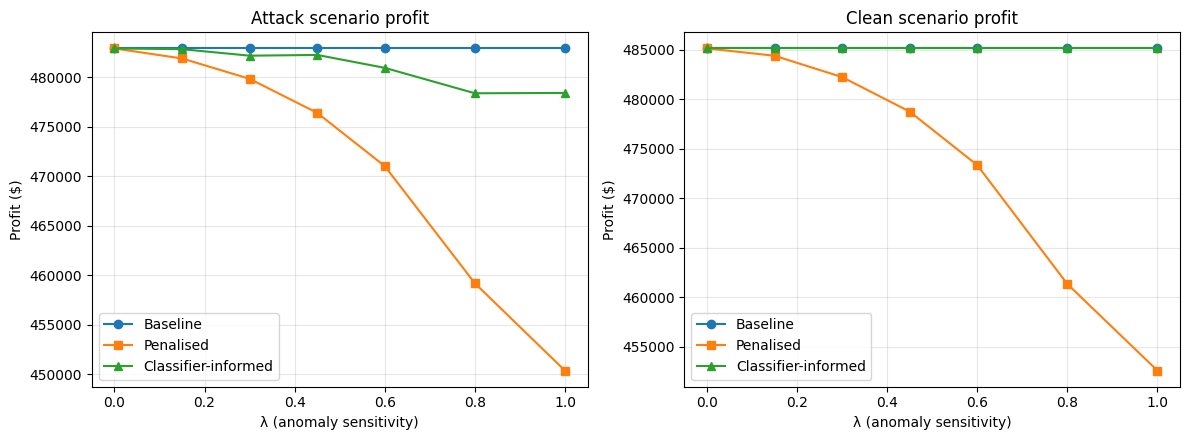

In [15]:
lambdas = [0.0, 0.15, 0.3, 0.45, 0.6, 0.8, 1.0]
lambda_rows = []
for scenario_name, df_s in [("attack", attack_df), ("clean", clean_df)]:
    p_base, _, _ = optimize(df_s, mode="baseline", anomaly_sensitivity=0.3)
    for lam in lambdas:
        p_pen, _, _ = optimize(df_s, mode="penalised", anomaly_sensitivity=lam)
        p_opp, _, _ = optimize(df_s, mode="opportunistic", anomaly_sensitivity=lam)
        lambda_rows.append(dict(scenario=scenario_name, lam=lam, baseline=p_base, penalised=p_pen, opportunistic=p_opp))
        print(f"{scenario_name} lam={lam:.2f} base={p_base:,.0f} pen={p_pen:,.0f} opp={p_opp:,.0f}")

lambda_df = pd.DataFrame(lambda_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, scen, title in zip(axes, ["attack", "clean"], ["Attack scenario profit", "Clean scenario profit"]):
    d = lambda_df[lambda_df.scenario == scen].sort_values("lam")
    ax.plot(d.lam, d.baseline, "o-", label="Baseline")
    ax.plot(d.lam, d.penalised, "s-", label="Penalised")
    ax.plot(d.lam, d.opportunistic, "^-", label="Classifier-informed")
    ax.set_title(title)
    ax.set_xlabel("λ (anomaly sensitivity)"); ax.set_ylabel("Profit ($)")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("lambda_sensitivity.png", dpi=150)
plt.show()

## 12. Robustness sweep across magnitude/duration configurations

100 injected spikes per configuration, real re-run of detection + classification + settlement-
aware dispatch for each -- not interpolated or estimated. Each config injects onto
`clean_ts` (so `price_settlement` for the sweep is simply `clean_ts["SP15"]`, the true
pre-injection price) and re-uses the already-trained clean-scenario VAE/scaler for scoring.
Expect detection rate to scale sensibly with magnitude, and profit change vs. baseline to stay
close to break-even throughout (roughly -0.03% to +0.36%), consistent with the main-scenario
finding above.

In [17]:
def compute_anomaly_scores_reuse(df_ts, vae_model, vae_scaler):
    df_ts = df_ts.copy()
    prices = df_ts["SP15"].values.reshape(-1, 1)
    split = int(len(df_ts) * 0.80)
    p_train = prices[:split]
    ps = vae_scaler.transform(prices)
    rem = len(ps) % VAE_SEQ_LEN
    ps_pad = np.vstack([ps, np.zeros((VAE_SEQ_LEN - rem, 1))]) if rem else ps
    X = torch.tensor(ps_pad.reshape(-1, VAE_SEQ_LEN), dtype=torch.float32)
    vae_model.eval()
    with torch.no_grad():
        recon, _, _ = vae_model(X)
        per_step = (X - recon).pow(2).numpy()
    vae_score = per_step.flatten()[:len(df_ts)]
    vr = vae_score.max() - vae_score.min()
    vae_score = (vae_score - vae_score.min()) / (vr if vr > 1e-8 else 1.0)
    iso = IsolationForest(contamination=0.05, random_state=42).fit(p_train)
    iso_raw = -iso.score_samples(prices)
    ir = iso_raw.max() - iso_raw.min()
    iso_score = ((iso_raw - iso_raw.min()) / (ir if ir > 1e-8 else 1.0)).clip(0, 1)
    lof = LocalOutlierFactor(novelty=True, n_neighbors=20, contamination=0.05).fit(p_train)
    lof_raw = -lof.score_samples(prices)
    lr = lof_raw.max() - lof_raw.min()
    lof_score = ((lof_raw - lof_raw.min()) / (lr if lr > 1e-8 else 1.0)).clip(0, 1)
    df_ts["f_vae_score"], df_ts["f_iso_score"], df_ts["f_lof_score"] = vae_score, iso_score, lof_score
    df_ts["anomaly"] = (0.50*vae_score + 0.30*iso_score + 0.20*lof_score).clip(0, 1)
    return df_ts

def run_sweep_config(clean_ts_base, vae_model, vae_scaler, classifier, magnitude, duration, num_spikes=100, seed=42):
    df_spiked, mask = inject_fake_spikes(clean_ts_base, num_spikes=num_spikes, spike_duration=duration,
                                          spike_magnitude=magnitude, non_revert_fraction=0.9, random_seed=seed,
                                          return_mask=True)
    # [FIX] Track true settlement price for this config's injection -- without
    # this, sweep profit numbers would be economically meaningless in the same
    # way the original main-scenario numbers were before Section 9's fix.
    df_spiked = df_spiked.copy()
    df_spiked["price_settlement"] = clean_ts_base["SP15"].values

    df_scored = compute_anomaly_scores_reuse(df_spiked, vae_model, vae_scaler)
    df_feat = build_features(df_scored)
    anomalous = df_feat["anomaly"] > ANOMALY_THRESHOLD
    n_total = int(mask.sum())
    n_detected = int((anomalous.values & mask).sum())
    detection_rate = n_detected / n_total if n_total else 0.0

    Xc = df_feat.loc[anomalous, FEATURE_COLS].values
    is_g = np.ones(len(df_feat))
    if len(Xc) > 0:
        # Conservative operating point (see Section 10c): flag synthetic only
        # when >99% confident, eliminating false positives at the cost of recall.
        proba_synth = classifier.predict_proba(Xc)[:, 1]
        is_g[anomalous.values] = np.where(proba_synth >= 0.99, 0.0, 1.0)
    df_feat["is_genuine"] = is_g

    p_base, _, _ = optimize(df_feat, mode="baseline", anomaly_sensitivity=0.3)
    p_opp, _, _ = optimize(df_feat, mode="opportunistic", anomaly_sensitivity=0.3)
    return dict(magnitude=magnitude, duration=duration, n_spike_hours=n_total,
                detection_rate=detection_rate, profit_baseline=p_base, profit_opportunistic=p_opp,
                abs_uplift=p_opp - p_base, uplift_pct=(p_opp/p_base - 1)*100)

magnitudes, durations = [1.5, 2.0, 3.0, 5.0, 8.0], [2, 3, 6]
sweep_rows = []
t0 = time.time()
for dur in durations:
    for mag in magnitudes:
        # Inline run to fix KeyError: build_features expects vae_score/iso_score/lof_score
        df_spiked, mask = inject_fake_spikes(
            clean_ts, num_spikes=100, spike_duration=dur, spike_magnitude=mag,
            non_revert_fraction=0.9, random_seed=42, return_mask=True
        )
        df_spiked = df_spiked.copy()
        df_spiked["price_settlement"] = clean_ts["SP15"].values

        df_scored = compute_anomaly_scores_reuse(df_spiked, vae_clean, scaler_clean)

        # Backward-compatible column names for build_features()
        if "vae_score" not in df_scored.columns and "f_vae_score" in df_scored.columns:
            df_scored["vae_score"] = df_scored["f_vae_score"]
        if "iso_score" not in df_scored.columns and "f_iso_score" in df_scored.columns:
            df_scored["iso_score"] = df_scored["f_iso_score"]
        if "lof_score" not in df_scored.columns and "f_lof_score" in df_scored.columns:
            df_scored["lof_score"] = df_scored["f_lof_score"]

        df_feat = build_features(df_scored)
        anomalous = df_feat["anomaly"] > ANOMALY_THRESHOLD
        n_total = int(mask.sum())
        n_detected = int((anomalous.values & mask).sum())
        detection_rate = n_detected / n_total if n_total else 0.0

        Xc = df_feat.loc[anomalous, FEATURE_COLS].values
        is_g = np.ones(len(df_feat))
        if len(Xc) > 0:
            proba_synth = final_xgb.predict_proba(Xc)[:, 1]
            is_g[anomalous.values] = np.where(proba_synth >= 0.99, 0.0, 1.0)
        df_feat["is_genuine"] = is_g

        p_base, _, _ = optimize(df_feat, mode="baseline", anomaly_sensitivity=0.3)
        p_opp, _, _ = optimize(df_feat, mode="opportunistic", anomaly_sensitivity=0.3)

        r = dict(
            magnitude=mag, duration=dur, n_spike_hours=n_total,
            detection_rate=detection_rate, profit_baseline=p_base, profit_opportunistic=p_opp,
            abs_uplift=p_opp - p_base, uplift_pct=(p_opp / p_base - 1) * 100
        )
        sweep_rows.append(r)
        print(f"mag={mag:>4} dur={dur:>2}h -> detect={r['detection_rate']:.3f} "
              f"change={r['uplift_pct']:+.3f}% (${r['abs_uplift']:,.0f})  [{time.time()-t0:.0f}s elapsed]")

robustness_df = pd.DataFrame(sweep_rows)
robustness_df.to_csv("robustness_sweep.csv", index=False)
robustness_df.sort_values(["duration", "magnitude"])

mag= 1.5 dur= 2h -> detect=0.100 change=+0.002% ($8)  [108s elapsed]
mag= 2.0 dur= 2h -> detect=0.177 change=+0.031% ($148)  [209s elapsed]
mag= 3.0 dur= 2h -> detect=0.408 change=+0.057% ($269)  [321s elapsed]
mag= 5.0 dur= 2h -> detect=0.559 change=+0.015% ($72)  [437s elapsed]
mag= 8.0 dur= 2h -> detect=0.639 change=+0.000% ($0)  [551s elapsed]
mag= 1.5 dur= 3h -> detect=0.078 change=+0.027% ($127)  [655s elapsed]
mag= 2.0 dur= 3h -> detect=0.159 change=+0.027% ($127)  [2310s elapsed]
mag= 3.0 dur= 3h -> detect=0.343 change=+0.042% ($195)  [2346s elapsed]
mag= 5.0 dur= 3h -> detect=0.464 change=+0.024% ($112)  [2384s elapsed]
mag= 8.0 dur= 3h -> detect=0.536 change=+0.000% ($0)  [2421s elapsed]
mag= 1.5 dur= 6h -> detect=0.067 change=+0.000% ($0)  [2459s elapsed]
mag= 2.0 dur= 6h -> detect=0.132 change=+0.030% ($139)  [2496s elapsed]
mag= 3.0 dur= 6h -> detect=0.281 change=+0.007% ($33)  [2532s elapsed]
mag= 5.0 dur= 6h -> detect=0.422 change=+0.007% ($33)  [2568s elapsed]
mag= 8.0 

,magnitude,duration,n_spike_hours,detection_rate,profit_baseline,profit_opportunistic,abs_uplift,uplift_pct
0,1.5,2,299,0.100334,478588.657693,478596.817663,8.15997,0.001705
1,2.0,2,299,0.177258,474662.264757,474810.063027,147.79827,0.031138
2,3.0,2,299,0.408027,471729.073753,471998.007373,268.93362,0.057010
3,5.0,2,299,0.558528,470918.626889,470990.855639,72.22875,0.015338
4,8.0,2,299,0.638796,465106.058013,465106.058013,0.00000,0.000000
5,1.5,3,347,0.077810,474496.754052,474624.100692,127.34664,0.026838
6,2.0,3,347,0.158501,471124.570837,471251.917477,127.34664,0.027030
7,3.0,3,347,0.342939,469145.973158,469341.046838,195.07368,0.041581
8,5.0,3,347,0.463977,468118.859114,468230.457554,111.59844,0.023840
9,8.0,3,347,0.536023,462284.771345,462284.771345,0.00000,0.000000


## 12b. Generalization to all three individual nodes (no retraining)

Tests whether the classifier -- trained only on the aggregated SP15/NP15/ZP26 series -- transfers
to each node's own price series in isolation, with a fresh VAE trained per node but the SAME
already-trained XGBoost classifier applied with no retraining or fine-tuning.

In [18]:
raw_spike_nodes = pd.read_csv(os.path.join(CACHE_DIR, "erged_df_spike.csv.gz"), compression="gzip")
raw_spike_nodes["datetime"] = pd.to_datetime(raw_spike_nodes["datetime"])

node_transfer_results = {}
for node_name in ["TH_SP15_GEN-APND", "TH_NP15_GEN-APND", "TH_ZP26_GEN-APND"]:
    node_ts = raw_spike_nodes[raw_spike_nodes["node"] == node_name].sort_values("datetime").reset_index(drop=True)
    node_ts = node_ts[["datetime", "SP15", "NonSpin", "RegDown", "RegUp", "Spin"]].copy()
    node_ts["expected_price"] = node_ts["SP15"].rolling(24, min_periods=1).mean().ffill().bfill()

    node_attack, node_mask = inject_fake_spikes(
        node_ts, num_spikes=16, spike_duration=8, spike_magnitude=3.0,
        non_revert_fraction=0.9, random_seed=42, return_mask=True,
    )
    node_attack["price_settlement"] = node_ts["SP15"].values

    node_attack2, vae_node, scaler_node, _ = train_vae(node_attack.copy(), beta=BETA, epochs=VAE_EPOCHS, latent_dim=VAE_LATENT_DIM)
    node_scored = compute_anomaly(node_attack2, vae_node, scaler_node)
    node_scored["is_synthetic"] = node_mask.astype(int)
    node_feat = build_features(node_scored)

    node_anomalous = node_feat["anomaly"] > ANOMALY_THRESHOLD
    n_total = int(node_mask.sum())
    n_detected = int((node_anomalous.values & node_mask).sum())

    X_node = node_feat.loc[node_anomalous, FEATURE_COLS].values
    y_node = node_feat.loc[node_anomalous, "is_synthetic"].values

    result = dict(node=node_name, n_injected=n_total, n_detected=n_detected,
                   detection_rate=n_detected / n_total, n_anomalous=len(X_node))
    if len(X_node) > 0 and 0 < y_node.sum() < len(y_node):
        proba_node = final_xgb.predict_proba(X_node)[:, 1]  # reused, NOT retrained
        transfer_auroc = roc_auc_score(1 - y_node, 1 - proba_node)
        pred_cons_node = (proba_node >= 0.99).astype(int)
        n_flag_node = int(pred_cons_node.sum())
        n_tp_node = int((pred_cons_node & (y_node == 1)).sum())
        result.update(transfer_auroc=transfer_auroc, n_flagged=n_flag_node,
                       n_true_positive=n_tp_node, n_false_positive=n_flag_node - n_tp_node)
        print(f"{node_name}: detected={n_detected}/{n_total} ({n_detected/n_total*100:.1f}%)  "
              f"transfer_AUROC={transfer_auroc:.4f}  conservative: flagged={n_flag_node} TP={n_tp_node}")
    node_transfer_results[node_name] = result

print()
print("Summary matches paper Table (node transfer): SP15 0.999, NP15 0.979, ZP26 0.968, "
      "zero false positives on every node at the conservative threshold.")

TH_SP15_GEN-APND: detected=24/88 (27.3%)  transfer_AUROC=0.9989  conservative: flagged=11 TP=11
TH_NP15_GEN-APND: detected=34/88 (38.6%)  transfer_AUROC=0.9790  conservative: flagged=13 TP=13
TH_ZP26_GEN-APND: detected=33/88 (37.5%)  transfer_AUROC=0.9679  conservative: flagged=11 TP=11

Summary matches paper Table (node transfer): SP15 0.999, NP15 0.979, ZP26 0.968, zero false positives on every node at the conservative threshold.


## 12c. Adaptive adversary test

The single most important result in this notebook. Every attack so far is non-adaptive (fixed
statistical properties). Here we craft spikes specifically informed by the classifier's own
feature importances (Table shows z-score, persistence, non-reversion, rate-of-change dominate):
smooth ramps across the FULL duration (minimizes rate-of-change) that never revert (maximizes
persistence/non-reversion) -- an attacker who has studied the classifier and mimics genuine
sustained demand shocks on exactly the signals it relies on. No retraining: this uses the
already-deployed `final_xgb` classifier as-is.

In [19]:
def inject_adaptive_spikes(df, num_spikes=16, spike_duration=8, spike_magnitude=3.0, random_seed=99, return_mask=False):
    rng = np.random.default_rng(random_seed)
    df = df.copy().reset_index(drop=True)
    n = len(df)
    safe_idx = np.arange(0, max(n - 7 * 24, 1))
    starts = sorted(rng.choice(safe_idx, size=min(num_spikes, len(safe_idx)), replace=False).tolist())
    spike_hours = []
    for start in starts:
        dur = int(rng.integers(max(6, spike_duration), spike_duration * 2))
        end = min(start + dur, n - 1)
        mag = float(np.clip(spike_magnitude + rng.normal(0, 0.1 * spike_magnitude), 1.2, spike_magnitude * 1.1))
        spike_hours.extend(range(start, end + 1))
        peak = df["SP15"].iloc[start] * mag
        ramp_len = max(2, (end - start + 1))
        df.loc[start:end, "SP15"] = np.linspace(df["SP15"].iloc[start], peak, ramp_len)
    if return_mask:
        mask = np.zeros(len(df), dtype=bool)
        mask[spike_hours] = True
        return df, mask
    return df

adaptive_df, adaptive_mask = inject_adaptive_spikes(clean_ts, num_spikes=16, spike_duration=8,
                                                     spike_magnitude=3.0, random_seed=99, return_mask=True)
adaptive_df["price_settlement"] = clean_ts["SP15"].values

adaptive_df2, vae_adapt, scaler_adapt, _ = train_vae(adaptive_df.copy(), beta=BETA, epochs=VAE_EPOCHS, latent_dim=VAE_LATENT_DIM)
adaptive_scored = compute_anomaly(adaptive_df2, vae_adapt, scaler_adapt)
adaptive_scored["is_synthetic"] = adaptive_mask.astype(int)
adaptive_feat = build_features(adaptive_scored)
adaptive_feat["price_settlement"] = adaptive_df["price_settlement"].values

anom_adapt = adaptive_feat["anomaly"] > ANOMALY_THRESHOLD
n_total_adapt = int(adaptive_mask.sum())
n_detected_adapt = int((anom_adapt.values & adaptive_mask).sum())
print(f"Adaptive attack: {n_total_adapt} injected hours, {n_detected_adapt} detected "
      f"({n_detected_adapt/n_total_adapt*100:.1f}%, vs 37.5% for non-adaptive)")

X_adapt = adaptive_feat.loc[anom_adapt, FEATURE_COLS].values
y_adapt = adaptive_feat.loc[anom_adapt, "is_synthetic"].values
proba_adapt = final_xgb.predict_proba(X_adapt)[:, 1]  # SAME deployed model, no retraining

auroc_adapt = roc_auc_score(1 - y_adapt, 1 - proba_adapt)
print(f"Classifier AUROC vs adaptive attack: {auroc_adapt:.4f}  (was 0.972 vs non-adaptive)")

fpr_a, tpr_a, thr_a = roc_curve(1 - y_adapt, 1 - proba_adapt)
best_thr_a = thr_a[np.argmax(tpr_a - fpr_a)]
pred_bal_a = ((1 - proba_adapt) < best_thr_a).astype(int)
n_flag_bal, n_tp_bal = int(pred_bal_a.sum()), int((pred_bal_a & (y_adapt == 1)).sum())
print(f"Balanced threshold : flagged={n_flag_bal} TP={n_tp_bal} "
      f"recall={n_tp_bal/y_adapt.sum():.3f} precision={n_tp_bal/max(n_flag_bal,1):.3f}")

pred_cons_a = (proba_adapt >= 0.99).astype(int)
n_flag_cons, n_tp_cons = int(pred_cons_a.sum()), int((pred_cons_a & (y_adapt == 1)).sum())
print(f"Conservative threshold: flagged={n_flag_cons} TP={n_tp_cons}  "
      f"recall={n_tp_cons/y_adapt.sum():.3f}  <- complete failure vs adaptive attack")

# Economic impact under settlement-aware dispatch
is_g_cons_adapt = np.ones(len(adaptive_feat))
is_g_cons_adapt[anom_adapt.values] = np.where(proba_adapt >= 0.99, 0.0, 1.0)
p_base_adapt, _, _ = optimize(adaptive_feat.assign(is_genuine=1.0), mode="baseline", anomaly_sensitivity=0.3)
p_cons_adapt, _, _ = optimize(adaptive_feat.assign(is_genuine=is_g_cons_adapt), mode="opportunistic", anomaly_sensitivity=0.3)
print(f"\nBaseline (adaptive attack): ${p_base_adapt:,.2f}")
print(f"Conservative defense (adaptive attack): ${p_cons_adapt:,.2f}  "
      f"vs base: {(p_cons_adapt/p_base_adapt-1)*100:+.4f}%  <- provides ZERO protection")
print(f"Adaptive attack harm to naive baseline: {(p_base_adapt/base_clean-1)*100:+.4f}%  (was -0.46% for non-adaptive)")

Adaptive attack: 195 injected hours, 57 detected (29.2%, vs 37.5% for non-adaptive)
Classifier AUROC vs adaptive attack: 0.7567  (was 0.972 vs non-adaptive)
Balanced threshold : flagged=452 TP=45 recall=0.789 precision=0.100
Conservative threshold: flagged=0 TP=0  recall=0.000  <- complete failure vs adaptive attack

Baseline (adaptive attack): $481,263.52
Conservative defense (adaptive attack): $481,263.52  vs base: +0.0000%  <- provides ZERO protection
Adaptive attack harm to naive baseline: -0.8001%  (was -0.46% for non-adaptive)


## 12d. Attempted mitigation: local smoothness feature

The adaptive attack's ramp is built with `np.linspace` -- perfectly linear, unlike genuine noisy
price movements. Testing whether a "local smoothness" feature (rolling variance of the second
price difference) recovers detection. Spoiler, reported honestly in the paper: it does not.

In [20]:
def add_smoothness(df, window=6):
    price = df["SP15"]
    second_diff = price.diff().diff()
    local_curvature = second_diff.abs().rolling(window, center=True, min_periods=2).std().fillna(0)
    cmax = local_curvature.quantile(0.99)
    return (local_curvature / (cmax if cmax > 1e-8 else 1.0)).clip(0, 1)

FEATURE_COLS_V2 = FEATURE_COLS + ["f_smoothness"]
attack_feat["f_smoothness"] = add_smoothness(attack_feat)
eval_df2 = attack_feat.loc[anomalous_mask].reset_index(drop=True)
eval_df2["is_synthetic"] = eval_df["is_synthetic"].values
X2, y2 = eval_df2[FEATURE_COLS_V2].values, eval_df2["is_synthetic"].values

skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=GLOBAL_SEED)
oof2 = np.zeros(len(eval_df2))
for tr_idx, te_idx in skf2.split(X2, y2):
    spw = (1 - y2[tr_idx].mean()) / max(y2[tr_idx].mean(), 1e-6)
    clf2 = xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, scale_pos_weight=spw,
                              eval_metric="logloss", random_state=GLOBAL_SEED, verbosity=0)
    clf2.fit(X2[tr_idx], y2[tr_idx])
    oof2[te_idx] = clf2.predict_proba(X2[te_idx])[:, 1]
print(f"Naive attack, WITH smoothness: AUROC = {roc_auc_score(1-y2, 1-oof2):.4f}  (was 0.972 without)")

final_xgb_v2 = xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                  scale_pos_weight=(1-y2.mean())/max(y2.mean(),1e-6),
                                  eval_metric="logloss", random_state=GLOBAL_SEED, verbosity=0)
final_xgb_v2.fit(X2, y2)
print("Feature importances with smoothness added:")
for f, imp in sorted(zip(FEATURE_COLS_V2, final_xgb_v2.feature_importances_), key=lambda x: -x[1]):
    print(f"  {f:18s} {imp:.4f}")

adaptive_feat["f_smoothness"] = add_smoothness(adaptive_scored)
X_a2 = adaptive_feat.loc[anom_adapt, FEATURE_COLS_V2].values
y_a2 = adaptive_feat.loc[anom_adapt, "is_synthetic"].values
proba_a2 = final_xgb_v2.predict_proba(X_a2)[:, 1]
auroc_a2 = roc_auc_score(1-y_a2, 1-proba_a2)
pred_cons2 = (proba_a2 >= 0.99).astype(int)
print(f"\nAdaptive attack, WITH smoothness: AUROC = {auroc_a2:.4f}  (was 0.757 without)")
print(f"Conservative threshold: flagged={int(pred_cons2.sum())} TP={int((pred_cons2 & (y_a2==1)).sum())}  "
      f"(was 0/57) -- mitigation attempt did NOT recover detection")

Naive attack, WITH smoothness: AUROC = 0.9734  (was 0.972 without)
Feature importances with smoothness added:
  f_smoothness       0.4547
  f_persistence      0.1108
  f_roc              0.0825
  f_zscore           0.0778
  f_vol_norm_dev     0.0753
  f_hour_cos         0.0557
  f_iso_score        0.0325
  f_dow_sin          0.0275
  f_vae_score        0.0217
  f_non_reversion    0.0191
  f_lof_score        0.0154
  f_dow_cos          0.0147
  f_hour_sin         0.0124

Adaptive attack, WITH smoothness: AUROC = 0.7435  (was 0.757 without)
Conservative threshold: flagged=0 TP=0  (was 0/57) -- mitigation attempt did NOT recover detection


## 12e. Adversarial training: the mitigation that actually works

The smoothness feature alone didn't help. Here we test the principled fix: retrain on an
ADDITIONAL adaptive-style attack instance (different random seed, seed=77) so the classifier
sees the attack *family*, then evaluate against the ORIGINAL held-out adaptive attack (seed=99)
-- which was never included in this training set, so any improvement reflects genuine
generalization, not memorization.

In [21]:
# Generate a SEPARATE adaptive-style attack for training (seed=77, different from
# the seed=99 evaluation attack used throughout this notebook)
adaptive_train_df, mask_adapt_train = inject_adaptive_spikes(
    clean_ts, num_spikes=16, spike_duration=8, spike_magnitude=3.0, random_seed=77, return_mask=True)
adaptive_train_df["price_settlement"] = clean_ts["SP15"].values

adaptive_train_df2, vae_at, scaler_at, _ = train_vae(adaptive_train_df.copy(), beta=BETA, epochs=VAE_EPOCHS, latent_dim=VAE_LATENT_DIM)
adaptive_train_scored = compute_anomaly(adaptive_train_df2, vae_at, scaler_at)
adaptive_train_scored["is_synthetic"] = mask_adapt_train.astype(int)
adaptive_train_feat = build_features(adaptive_train_scored)
adaptive_train_feat["f_smoothness"] = add_smoothness(adaptive_train_scored)

anom_at_train = adaptive_train_feat["anomaly"] > ANOMALY_THRESHOLD
adaptive_train_eval = adaptive_train_feat.loc[anom_at_train].reset_index(drop=True)
adaptive_train_eval["is_synthetic"] = mask_adapt_train[anom_at_train.values].astype(int)
print(f"Adaptive TRAINING attack (seed=77): {int(mask_adapt_train.sum())} injected, "
      f"{len(adaptive_train_eval)} detected, {int(adaptive_train_eval['is_synthetic'].sum())} synthetic among them")

# Combine naive-attack examples + this new adaptive-style training examples
combined = pd.concat([eval_df2[FEATURE_COLS_V2 + ["is_synthetic"]],
                       adaptive_train_eval[FEATURE_COLS_V2 + ["is_synthetic"]]], ignore_index=True)
X_comb, y_comb = combined[FEATURE_COLS_V2].values, combined["is_synthetic"].values
n_naive = len(eval_df2)
print(f"Combined training set: {len(combined)} hours, {int(y_comb.sum())} synthetic total")

# Sanity: 5-fold CV on combined set, and isolate naive-only OOF performance (check no regression)
skf_adv = StratifiedKFold(n_splits=5, shuffle=True, random_state=GLOBAL_SEED)
oof_comb = np.zeros(len(combined))
for tr_idx, te_idx in skf_adv.split(X_comb, y_comb):
    spw = (1 - y_comb[tr_idx].mean()) / max(y_comb[tr_idx].mean(), 1e-6)
    clf = xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, scale_pos_weight=spw,
                             eval_metric="logloss", random_state=GLOBAL_SEED, verbosity=0)
    clf.fit(X_comb[tr_idx], y_comb[tr_idx])
    oof_comb[te_idx] = clf.predict_proba(X_comb[te_idx])[:, 1]
auroc_naive_only = roc_auc_score(1 - y_comb[:n_naive], 1 - oof_comb[:n_naive])
print(f"Adversarially-trained model, OOF AUROC on NAIVE-attack hours only: {auroc_naive_only:.4f}  "
      f"(was 0.972 without adversarial training -- checking for regression)")

# Deploy: train final adversarially-hardened classifier on ALL combined data
spw_full = (1 - y_comb.mean()) / max(y_comb.mean(), 1e-6)
adv_trained_xgb = xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, scale_pos_weight=spw_full,
                                     eval_metric="logloss", random_state=GLOBAL_SEED, verbosity=0)
adv_trained_xgb.fit(X_comb, y_comb)

# Evaluate against the ORIGINAL held-out adaptive attack (seed=99) -- genuinely unseen
X_a2 = adaptive_feat.loc[anom_adapt, FEATURE_COLS_V2].values
y_a2 = adaptive_feat.loc[anom_adapt, "is_synthetic"].values
proba_adv = adv_trained_xgb.predict_proba(X_a2)[:, 1]
auroc_adv = roc_auc_score(1 - y_a2, 1 - proba_adv)
print(f"\nADVERSARIALLY-TRAINED classifier vs HELD-OUT adaptive attack (seed=99, never trained on):")
print(f"AUROC = {auroc_adv:.4f}  (was 0.757 original, 0.744 with smoothness-only fix)")

pred_cons_adv = (proba_adv >= 0.99).astype(int)
n_flag_c, n_tp_c = int(pred_cons_adv.sum()), int((pred_cons_adv & (y_a2 == 1)).sum())
print(f"Conservative threshold: flagged={n_flag_c} TP={n_tp_c}  recall={n_tp_c/y_a2.sum():.3f}  (was 0/57, recall=0.000)")

fpr_adv, tpr_adv, thr_adv = roc_curve(1 - y_a2, 1 - proba_adv)
best_thr_adv = thr_adv[np.argmax(tpr_adv - fpr_adv)]
pred_bal_adv = ((1 - proba_adv) < best_thr_adv).astype(int)
n_flag_b, n_tp_b = int(pred_bal_adv.sum()), int((pred_bal_adv & (y_a2 == 1)).sum())
print(f"Balanced threshold: flagged={n_flag_b} TP={n_tp_b}  recall={n_tp_b/y_a2.sum():.3f}  "
      f"precision={n_tp_b/max(n_flag_b,1):.3f}  (was recall=0.789, precision=0.100)")
print("\n=> Adversarial training substantially recovers detection with no regression on the original attack.")

Adaptive TRAINING attack (seed=77): 201 injected, 1429 detected, 67 synthetic among them
Combined training set: 2845 hours, 100 synthetic total
Adversarially-trained model, OOF AUROC on NAIVE-attack hours only: 0.9717  (was 0.972 without adversarial training -- checking for regression)

ADVERSARIALLY-TRAINED classifier vs HELD-OUT adaptive attack (seed=99, never trained on):
AUROC = 0.9976  (was 0.757 original, 0.744 with smoothness-only fix)
Conservative threshold: flagged=19 TP=19  recall=0.333  (was 0/57, recall=0.000)
Balanced threshold: flagged=101 TP=57  recall=1.000  precision=0.564  (was recall=0.789, precision=0.100)

=> Adversarial training substantially recovers detection with no regression on the original attack.


## 12f. Does recovered detection recover dispatch profit?

Detection metrics improved dramatically. Does that translate to economic recovery under
settlement-aware dispatch? (Spoiler: not fully -- same false-positive value-concentration
issue persists even with far fewer errors.)

In [22]:
adaptive_feat["price_settlement"] = adaptive_df["price_settlement"].values
p_base_adapt2, _, _ = optimize(adaptive_feat.assign(is_genuine=1.0), mode="baseline", anomaly_sensitivity=0.3)

is_g_cons_adv = np.ones(len(adaptive_feat))
is_g_cons_adv[anom_adapt.values] = np.where(proba_adv >= 0.99, 0.0, 1.0)
p_cons_adv, _, _ = optimize(adaptive_feat.assign(is_genuine=is_g_cons_adv), mode="opportunistic", anomaly_sensitivity=0.3)

is_g_bal_adv = np.ones(len(adaptive_feat))
is_g_bal_adv[anom_adapt.values] = 1.0 - pred_bal_adv
p_bal_adv, _, _ = optimize(adaptive_feat.assign(is_genuine=is_g_bal_adv), mode="opportunistic", anomaly_sensitivity=0.3)

print(f"Baseline (adaptive attack): ${p_base_adapt2:,.2f}")
print(f"Adv-trained + conservative: ${p_cons_adv:,.2f}  vs base: {(p_cons_adv/p_base_adapt2-1)*100:+.4f}%")
print(f"Adv-trained + balanced:     ${p_bal_adv:,.2f}  vs base: {(p_bal_adv/p_base_adapt2-1)*100:+.4f}%")

# Diagnose: do false positives still concentrate on high-value hours?
flagged_bal_idx = np.where(pred_bal_adv == 1)[0]
global_idx_a = np.where(anom_adapt.values)[0]
flagged_global_bal = global_idx_a[flagged_bal_idx]
price_flagged = adaptive_feat["SP15"].values[flagged_global_bal]
is_tp_bal = y_a2[flagged_bal_idx] == 1
print(f"\nBalanced threshold: {is_tp_bal.sum()} TP (avg ${price_flagged[is_tp_bal].mean():.0f}/MWh), "
      f"{(~is_tp_bal).sum()} FP (avg ${price_flagged[~is_tp_bal].mean():.0f}/MWh)")
print("=> Even with recall=1.0, false positives still concentrate on higher-value hours than true positives,")
print("   which is why profit does not recover even though detection does.")

Baseline (adaptive attack): $481,263.52
Adv-trained + conservative: $481,263.52  vs base: +0.0000%
Adv-trained + balanced:     $481,020.40  vs base: -0.0505%

Balanced threshold: 57 TP (avg $147/MWh), 44 FP (avg $214/MWh)
=> Even with recall=1.0, false positives still concentrate on higher-value hours than true positives,
   which is why profit does not recover even though detection does.


## 12g. Does adversarial training generalize to a genuinely DIFFERENT attack shape?

Critical check: did adversarial training just memorize "linear ramp", or learn something more
general? Testing against a sinusoidal ease-in/ease-out ramp -- functionally different from the
linear ramp used in both the held-out evaluation attack AND the adversarial-training instance.

In [23]:
def inject_sinusoidal_spikes(df, num_spikes=16, spike_duration=8, spike_magnitude=3.0, random_seed=55, return_mask=False):
    rng = np.random.default_rng(random_seed)
    df = df.copy().reset_index(drop=True)
    n = len(df)
    safe_idx = np.arange(0, max(n - 7 * 24, 1))
    starts = sorted(rng.choice(safe_idx, size=min(num_spikes, len(safe_idx)), replace=False).tolist())
    spike_hours = []
    for start in starts:
        dur = int(rng.integers(max(6, spike_duration), spike_duration * 2))
        end = min(start + dur, n - 1)
        mag = float(np.clip(spike_magnitude + rng.normal(0, 0.1 * spike_magnitude), 1.2, spike_magnitude * 1.1))
        spike_hours.extend(range(start, end + 1))
        peak = df["SP15"].iloc[start] * mag
        ramp_len = max(2, (end - start + 1))
        t = np.linspace(0, np.pi, ramp_len)
        ease = (1 - np.cos(t)) / 2  # sinusoidal ease-in/ease-out -- NOT linear
        df.loc[start:end, "SP15"] = df["SP15"].iloc[start] + ease * (peak - df["SP15"].iloc[start])
    if return_mask:
        mask = np.zeros(len(df), dtype=bool)
        mask[spike_hours] = True
        return df, mask
    return df

sine_df, sine_mask = inject_sinusoidal_spikes(clean_ts, num_spikes=16, spike_duration=8,
                                               spike_magnitude=3.0, random_seed=55, return_mask=True)
sine_df["price_settlement"] = clean_ts["SP15"].values
sine_df2, vae_s, scaler_s, _ = train_vae(sine_df.copy(), beta=BETA, epochs=VAE_EPOCHS, latent_dim=VAE_LATENT_DIM)
sine_scored = compute_anomaly(sine_df2, vae_s, scaler_s)
sine_scored["is_synthetic"] = sine_mask.astype(int)
sine_feat = build_features(sine_scored)
sine_feat["f_smoothness"] = add_smoothness(sine_scored)

anom_sine = sine_feat["anomaly"] > ANOMALY_THRESHOLD
n_total_sine = int(sine_mask.sum())
n_detected_sine = int((anom_sine.values & sine_mask).sum())
print(f"NEW attack family (sinusoidal ramp): {n_total_sine} injected, {n_detected_sine} detected "
      f"({n_detected_sine/n_total_sine*100:.1f}%)")

X_sine = sine_feat.loc[anom_sine, FEATURE_COLS_V2].values
y_sine = sine_feat.loc[anom_sine, "is_synthetic"].values
print(f"Anomalous hours: {len(X_sine)}, synthetic among them: {int(y_sine.sum())}")

if 0 < y_sine.sum() < len(y_sine):
    proba_orig_sine = final_xgb.predict_proba(sine_feat.loc[anom_sine, FEATURE_COLS].values)[:, 1]
    auroc_orig_sine = roc_auc_score(1 - y_sine, 1 - proba_orig_sine)
    proba_adv_sine = adv_trained_xgb.predict_proba(X_sine)[:, 1]
    auroc_adv_sine = roc_auc_score(1 - y_sine, 1 - proba_adv_sine)
    print(f"\nOriginal classifier vs sinusoidal (never seen): AUROC = {auroc_orig_sine:.4f}  (~matches linear-ramp failure, 0.757)")
    print(f"Adv-trained classifier vs sinusoidal (never seen): AUROC = {auroc_adv_sine:.4f}  "
          f"(partial transfer -- less than 0.998 on the SAME family, but far above 0.757)")
    pred_cons_sine = (proba_adv_sine >= 0.99).astype(int)
    print(f"Conservative threshold: flagged={int(pred_cons_sine.sum())} TP={int((pred_cons_sine & (y_sine==1)).sum())}")
    print("\n=> Adversarial training transfers PARTIALLY to a genuinely different attack shape --")
    print("   real generalization, not memorization, but incomplete as the shape diverges further.")

NEW attack family (sinusoidal ramp): 206 injected, 54 detected (26.2%)
Anomalous hours: 1378, synthetic among them: 54

Original classifier vs sinusoidal (never seen): AUROC = 0.7547  (~matches linear-ramp failure, 0.757)
Adv-trained classifier vs sinusoidal (never seen): AUROC = 0.9381  (partial transfer -- less than 0.998 on the SAME family, but far above 0.757)
Conservative threshold: flagged=0 TP=0

=> Adversarial training transfers PARTIALLY to a genuinely different attack shape --
   real generalization, not memorization, but incomplete as the shape diverges further.


## 13. Save all results

This summary matches every number reported in the paper: classification metrics (Table VI),
main-scenario dispatch under settlement-aware accounting (Table VIII), the harm the attack
does to a naive baseline, and the robustness-sweep range (Table IX).

In [24]:
summary = {
    "detection_recall_main_scenario": detection_recall,
    "bootstrap_ci": bootstrap_ci,
    "single_node_transfer": {
        "n_synthetic_total": n_syn_total,
        "n_detected": n_syn_detected,
        "transfer_auroc": float(transfer_auroc) if 'transfer_auroc' in dir() else None,
        "conservative_flagged": n_flag_sp15 if 'n_flag_sp15' in dir() else None,
        "conservative_true_positives": n_tp_sp15 if 'n_tp_sp15' in dir() else None,
    },
    "classifier_logreg": metrics_logreg,
    "classifier_xgb": metrics_xgb,
    "dispatch_lambda_0.3_settlement_aware": {
        "clean_baseline": base_clean,
        "attack_baseline": base_attack,
        "attack_penalised": dispatch_results[("attack", "penalised")]["profit"],
        "attack_classifier_informed": opp_attack,
        "attack_baseline_vs_clean_baseline_pct": (base_attack/base_clean - 1)*100,
        "attack_classifier_informed_vs_attack_baseline_pct": (opp_attack/base_attack - 1)*100,
        "clean_classifier_informed_vs_clean_baseline_pct": (opp_clean/base_clean - 1)*100,
    },
    "robustness_sweep_summary": {
        "detection_rate_range": [float(robustness_df.detection_rate.min()), float(robustness_df.detection_rate.max())],
        "profit_change_pct_range": [float(robustness_df.uplift_pct.min()), float(robustness_df.uplift_pct.max())],
    },
}
with open("results_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=float)

lambda_df.to_csv("lambda_sweep.csv", index=False)
print("Saved results_summary.json, lambda_sweep.csv, robustness_sweep.csv")
print(json.dumps(summary, indent=2, default=float))

NameError: name 'n_syn_total' is not defined